# Pneumonia detection

In [1]:
# needed library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/labeled-chest-xray-images


In [3]:
dataset_path = path+'/chest_xray'

In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])

In [5]:
classes = ['PNEUMONIA', 'NORMAL']

train_dataset = datasets.ImageFolder(root=dataset_path+"/train", transform=train_transform)
test_dataset  = datasets.ImageFolder(root=dataset_path+"/test",  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

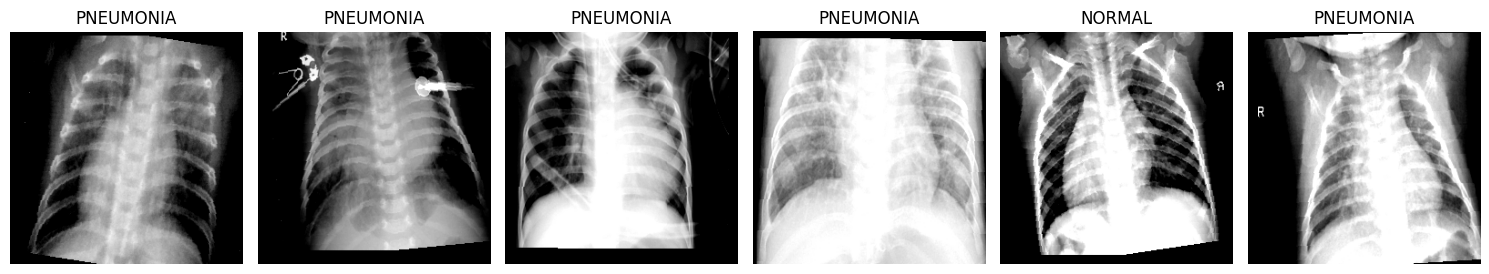

In [6]:
num_images = 6
indices = random.sample(range(len(train_dataset)), num_images)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    if isinstance(image, torch.Tensor):
        image = image * 0.5 + 0.5

    img_np = image.permute(1, 2, 0).numpy()

    plt.subplot(1, num_images, i + 1)
    if img_np.shape[2] == 1:
        plt.imshow(img_np.squeeze(), cmap='gray')
    else:
        plt.imshow(img_np)

    plt.title(train_dataset.classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
#spliting
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 1. EfficentNet


In [8]:
from torchvision import models

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Replace the classifier for binary classification
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)

# move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [10]:
num_epochs = 10
train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.sigmoid(outputs).data > 0.5
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_acc_list.append(train_acc)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            predicted = torch.sigmoid(outputs).data > 0.5
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/10], Train Acc: 0.9309, Val Acc: 0.9809
Epoch [2/10], Train Acc: 0.9732, Val Acc: 0.9819
Epoch [3/10], Train Acc: 0.9787, Val Acc: 0.9876
Epoch [4/10], Train Acc: 0.9823, Val Acc: 0.9847
Epoch [5/10], Train Acc: 0.9847, Val Acc: 0.9866
Epoch [6/10], Train Acc: 0.9878, Val Acc: 0.9876
Epoch [7/10], Train Acc: 0.9916, Val Acc: 0.9933
Epoch [8/10], Train Acc: 0.9907, Val Acc: 0.9895
Epoch [9/10], Train Acc: 0.9912, Val Acc: 0.9885
Epoch [10/10], Train Acc: 0.9912, Val Acc: 0.9904


In [13]:
from sklearn.metrics import classification_report

# لازم نحصل على كل التوقعات والتصنيفات الحقيقية
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).int().squeeze()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# طباعة التقرير
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

   PNEUMONIA       0.99      0.83      0.90       234
      NORMAL       0.91      0.99      0.95       390

    accuracy                           0.93       624
   macro avg       0.95      0.91      0.93       624
weighted avg       0.94      0.93      0.93       624



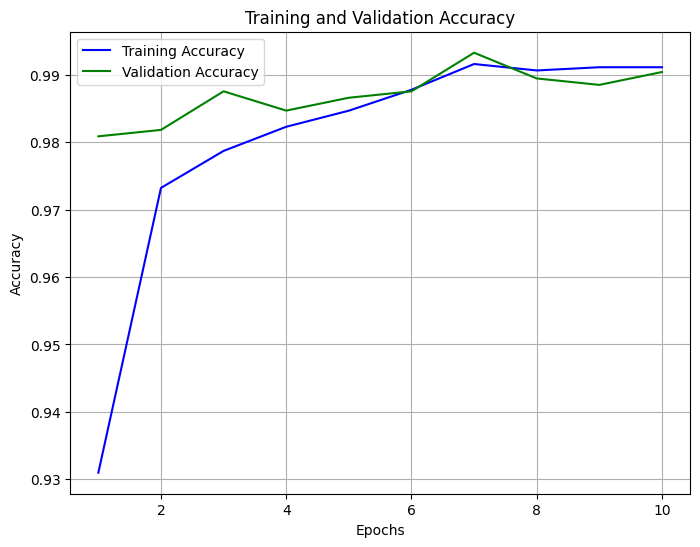

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_acc_list, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc_list, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
